# Week 3: MPOs

In [2]:
using Pkg
Pkg.activate("../")
using ITensors
using ITensorMPS
using Plots
using LinearAlgebra

  Activating project at `c:\Users\mariu\GithubCloneTN\TN_Notebooks`


## Exercise 1

Let us consider the XY model (with $\gamma=0$) discussed in the `Extended example` in the companion lecture-notebook `MPO_ITensor.ipynb`. 
This time we add a constant magnetic field in the $Z$ direction. The new Hamiltonian reads:
$$
H = -J \sum_{i=1}^{N-1} \sigma_-^{i} \sigma_+^{i+1} + \sigma_+^{i} \sigma_-^{i+1} -h \sum_{i=1}^N \sigma_z^i
$$ 
with $N=20$, $J = 1.0$ and $h=0.5$($\hbar = 1$).

 and the initial state $\ket{\psi_0} = \ket{\uparrow \downarrow \downarrow \ldots \downarrow}$ where only the first spin is "up" and all the others are down. Since $[H,N_z$] = 0$, $N_z$, i.e. the number of spins up is a constant of the motion. Thus $\left \{\ket{i} \right \}_{i=1}^N$ is a basis for the subspace of the Hilbert space of the system actually visited during the evolution.

1. Form the tridiagonal matrix representing $H$ in the $\ket{i}$ basis (see [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.Tridiagonal)).
2. Determine the solution of the eigensystem and the solutions $\psi(j,t)$ for the amplitudes of being at site $j$ at time $t$ as a function

`solExactHom(nn::Int, jj:Float, h::Float, t::Float)::Vector{ComplexF64}`

that takes the number of sites $N$, the value of the coupling constant $J$, the intensity of the magnetic field $h$ and the time $t$ and returns a vector of $N$ complex values $[\psi(1,t),\psi(2,t),\ldots,\psi(N,t)]$ with $\psi(j,t)$ the amplitude of the basis state $\ket{j}$ at time $t$.

3. Determine the amplitudes $[\psi(1,t),\psi(2,t),\ldots,\psi(N,t)]$ for $t=0, 0.1,0.2,\ldots,10$. 

Question: do we really need to compute the amplitudes? How does this Hamiltonian relate to the Hamiltonian used the `Extended example` of the companion lecture-notebook `MPO_ITensor.ipynb`?


In [3]:
#Construct the Sub Hamiltonian

J = 1.0
N = 20
h = 0.5
dl = -J*ones(ComplexF64, 19)

19-element Vector{ComplexF64}:
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im

In [4]:
d = -h*(N-2)*ones(ComplexF64, 20) # N-1 down, 1 up

20-element Vector{ComplexF64}:
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im
 -9.0 - 0.0im

In [5]:
du = dl

19-element Vector{ComplexF64}:
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im
 -1.0 - 0.0im

In [6]:
Tri = Tridiagonal(dl, d, du)

20×20 Tridiagonal{ComplexF64, Vector{ComplexF64}}:
 -9.0-0.0im  -1.0-0.0im       ⋅      …       ⋅           ⋅           ⋅    
 -1.0-0.0im  -9.0-0.0im  -1.0-0.0im          ⋅           ⋅           ⋅    
      ⋅      -1.0-0.0im  -9.0-0.0im          ⋅           ⋅           ⋅    
      ⋅           ⋅      -1.0-0.0im          ⋅           ⋅           ⋅    
      ⋅           ⋅           ⋅              ⋅           ⋅           ⋅    
      ⋅           ⋅           ⋅      …       ⋅           ⋅           ⋅    
      ⋅           ⋅           ⋅              ⋅           ⋅           ⋅    
      ⋅           ⋅           ⋅              ⋅           ⋅           ⋅    
      ⋅           ⋅           ⋅              ⋅           ⋅           ⋅    
      ⋅           ⋅           ⋅              ⋅           ⋅           ⋅    
      ⋅           ⋅           ⋅      …       ⋅           ⋅           ⋅    
      ⋅           ⋅           ⋅              ⋅           ⋅           ⋅    
      ⋅           ⋅           ⋅              ⋅   

In [7]:
# diag

eigenval, eigenvek = eigen(Tri)

Eigen{ComplexF64, Float64, Matrix{ComplexF64}, Vector{Float64}}
values:
20-element Vector{Float64}:
 -10.97766165245026
 -10.911145611572286
 -10.801937735804843
 -10.652477548631987
 -10.466103743659652
 -10.246979603717467
 -10.0
  -9.730682048732788
  -9.445041867912629
  -9.14946018717285
  -8.85053981282715
  -8.55495813208737
  -8.26931795126721
  -7.999999999999999
  -7.753020396282533
  -7.533896256340347
  -7.34752245136801
  -7.198062264195161
  -7.088854388427719
  -7.022338347549743
vectors:
20×20 Matrix{ComplexF64}:
 0.0459954-0.0im  -0.0909634-0.0im  …  -0.0909634-0.0im  -0.0459954-0.0im
 0.0909634-0.0im   -0.173844-0.0im       0.173844+0.0im   0.0909634+0.0im
  0.133899-0.0im   -0.241278-0.0im      -0.241278-0.0im   -0.133899-0.0im
  0.173844-0.0im   -0.287274-0.0im       0.287274+0.0im    0.173844+0.0im
  0.209906-0.0im   -0.307744-0.0im      -0.307744-0.0im   -0.209906-0.0im
  0.241278-0.0im   -0.300869-0.0im  …    0.300869+0.0im    0.241278+0.0im
  0.267261-0.0im   -0

In [8]:
# Calculate the time dept versions of the vectors

function solExactHam(nn::Int, jj::Float64, h::Float64, t::Float64)::Vector{ComplexF64}
    J = jj
    N = nn
    h = h
    dl = -J*ones(ComplexF64, nn-1)

    d = -h*(N-2)*ones(ComplexF64, nn) # N-1 down, 1 up
    du = dl
    Tri = Tridiagonal(dl, d, du)
    eigenval, eigenvek = eigen(Tri)

    # Initial state: (up, dn, dn, ...) -> (1, 0, 0) -> Projection on an eigenstate is the first component of that state.
    coeffs = eigenvek[1, :]
    #time evolution
    for l in range(1, N)
        coeffs[l] = coeffs[l]*exp( - 1im*t*eigenval[l])
    end

    # construct back to the state

    return eigenvek*coeffs
end
    
    

solExactHam (generic function with 1 method)

In [9]:
Psi_0 = zeros(N)
Psi_0[1] = 1

Psi_t = solExactHam(20, 1., 0.5, 1.)
norm(Psi_t)

1.0

In [10]:
timeStates = []
for te in 0:0.1:10
    push!(timeStates, solExactHam(20, 1., 0.5, te))
end
timeStates

101-element Vector{Any}:
 ComplexF64[1.0000000000000002 + 0.0im, -5.134781488891349e-16 + 0.0im, -8.326672684688674e-17 + 0.0im, 3.7470027081099033e-16 + 0.0im, 5.689893001203927e-16 + 0.0im, 3.191891195797325e-16 + 0.0im, -9.003214840319629e-16 + 0.0im, -4.649058915617843e-16 + 0.0im, 5.689893001203927e-16 + 0.0im, -1.5265566588595902e-16 + 0.0im, -4.49293380277993e-16 + 0.0im, 4.163336342344337e-16 + 0.0im, 3.8163916471489756e-16 + 0.0im, -2.7755575615628914e-17 + 0.0im, 1.734723475976807e-16 + 0.0im, -5.117434254131581e-16 + 0.0im, -1.4224732503009818e-16 + 0.0im, -9.367506770274758e-17 + 0.0im, -4.163336342344337e-17 + 0.0im, 2.393918396847994e-16 + 0.0im]
 ComplexF64[0.6185070941978019 + 0.7794167973665418im, -0.07807190816158509 + 0.06195405233586519im, -0.00310028748255943 - 0.00390685274791569im, 0.00013029359345537173 - 0.0001033946306425726im, 2.5857278809077178e-6 + 3.2584262376761375e-6im, -6.51840473646359e-8 + 5.1726876015151246e-8im, -8.622691501786184e-10 - 1.0865955704

## Exercise 2

Consider the Hamiltonian $H$ of the previous exercise. 

1. Design the bulk matrix and the bounday vectors producing the MPO (see Section 3.2.2 of the lecture notes) representation of $H$.
2. Determine the new MPO via `OpSum` and `MPO` constructs.
3. Check the bond dimension of the MPO: is it the same as the bond dimension in the absence of the $\sigma_z$ term (see Extended example)? Yes/no,why? How does the ITensor MPO bond dimension compare to the bond dimension of the bulk matrix/vectors determined at point 1?

In [11]:
# Define state in ITensorMPS

nn = 20
jj=1.0
system = siteinds("S=1/2",nn)
#Prepare the initial state as a product state with "Up" on the first site and "Dn" on the rest of the sites
psi0= MPS(ComplexF64,system,[(j==1) ? "Up" : "Dn" for j in 1:nn]);
#Set the orthogonality center to the first site
orthogonalize!(psi0,1)



20-element MPS:
 ((dim=2|id=112|"S=1/2,Site,n=1"), (dim=1|id=154|"Link,l=1"))
 ((dim=2|id=420|"S=1/2,Site,n=2"), (dim=1|id=811|"Link,l=2"), (dim=1|id=154|"Link,l=1"))
 ((dim=2|id=5|"S=1/2,Site,n=3"), (dim=1|id=729|"Link,l=3"), (dim=1|id=811|"Link,l=2"))
 ((dim=2|id=900|"S=1/2,Site,n=4"), (dim=1|id=801|"Link,l=4"), (dim=1|id=729|"Link,l=3"))
 ((dim=2|id=868|"S=1/2,Site,n=5"), (dim=1|id=607|"Link,l=5"), (dim=1|id=801|"Link,l=4"))
 ((dim=2|id=987|"S=1/2,Site,n=6"), (dim=1|id=152|"Link,l=6"), (dim=1|id=607|"Link,l=5"))
 ((dim=2|id=729|"S=1/2,Site,n=7"), (dim=1|id=179|"Link,l=7"), (dim=1|id=152|"Link,l=6"))
 ((dim=2|id=545|"S=1/2,Site,n=8"), (dim=1|id=450|"Link,l=8"), (dim=1|id=179|"Link,l=7"))
 ((dim=2|id=668|"S=1/2,Site,n=9"), (dim=1|id=973|"Link,l=9"), (dim=1|id=450|"Link,l=8"))
 ((dim=2|id=280|"S=1/2,Site,n=10"), (dim=1|id=306|"Link,l=10"), (dim=1|id=973|"Link,l=9"))
 ((dim=2|id=234|"S=1/2,Site,n=11"), (dim=1|id=696|"Link,l=11"), (dim=1|id=306|"Link,l=10"))
 ((dim=2|id=755|"S=1/2,Site,n

In [12]:
#define the hamiltonian

h = -0.5
opsum = OpSum()
for bond in 1:nn-1
    #note that the sintax allows for constants to appear before the operator string
    opsum += -1. * jj, "S-", bond, "S+", bond+1
    opsum += -1. * jj, "S+", bond, "S-", bond+1
end
for l in 1:nn
    opsum += h, "Z", l
end

ham = MPO(opsum, system)

20-element MPO:
 ((dim=4|id=359|"Link,l=1"), (dim=2|id=112|"S=1/2,Site,n=1")', (dim=2|id=112|"S=1/2,Site,n=1"))
 ((dim=4|id=359|"Link,l=1"), (dim=4|id=789|"Link,l=2"), (dim=2|id=420|"S=1/2,Site,n=2")', (dim=2|id=420|"S=1/2,Site,n=2"))
 ((dim=4|id=789|"Link,l=2"), (dim=4|id=976|"Link,l=3"), (dim=2|id=5|"S=1/2,Site,n=3")', (dim=2|id=5|"S=1/2,Site,n=3"))
 ((dim=4|id=976|"Link,l=3"), (dim=4|id=601|"Link,l=4"), (dim=2|id=900|"S=1/2,Site,n=4")', (dim=2|id=900|"S=1/2,Site,n=4"))
 ((dim=4|id=601|"Link,l=4"), (dim=4|id=381|"Link,l=5"), (dim=2|id=868|"S=1/2,Site,n=5")', (dim=2|id=868|"S=1/2,Site,n=5"))
 ((dim=4|id=381|"Link,l=5"), (dim=4|id=895|"Link,l=6"), (dim=2|id=987|"S=1/2,Site,n=6")', (dim=2|id=987|"S=1/2,Site,n=6"))
 ((dim=4|id=895|"Link,l=6"), (dim=4|id=886|"Link,l=7"), (dim=2|id=729|"S=1/2,Site,n=7")', (dim=2|id=729|"S=1/2,Site,n=7"))
 ((dim=4|id=886|"Link,l=7"), (dim=4|id=604|"Link,l=8"), (dim=2|id=545|"S=1/2,Site,n=8")', (dim=2|id=545|"S=1/2,Site,n=8"))
 ((dim=4|id=604|"Link,l=8"), (d

-> Bond dimension is now 4


Plots und Zeitevolution:

In [13]:
deltat = 0.1
nsteps = Int(round(10/deltat))
hdeltat = deltat * ham
#build an MPO with the operator "Id" on each site
theOne = MPO(system,"Id")
factor(k) = (-1im)^k / factorial(k)
#As not to have all the indices of hdeltat contracted with each other, we prime the second one and then we contract the first index of the second one with the first index of the first one, and then we lower the second prime level to first prime level.
h2 = mapprime(prime(hdeltat)*hdeltat,2 =>1)
h3 = mapprime(prime(hdeltat) * h2,2 =>1)
terms = [theOne, factor(1)*hdeltat, factor(2)*h2, factor(3)*h3];
appo = terms[1];
for t in terms[2:end]
    appo = t + appo
end
h4thOrder = appo;
#h4thOrder = +(terms...; cutoff=1e-18);

20-element MPO:
 ((dim=2|id=112|"S=1/2,Site,n=1")', (dim=2|id=112|"S=1/2,Site,n=1"), (dim=8|id=393|"Link,l=1"))
 ((dim=2|id=420|"S=1/2,Site,n=2")', (dim=2|id=420|"S=1/2,Site,n=2"), (dim=14|id=863|"Link,l=2"), (dim=8|id=393|"Link,l=1"))
 ((dim=2|id=5|"S=1/2,Site,n=3")', (dim=2|id=5|"S=1/2,Site,n=3"), (dim=14|id=356|"Link,l=3"), (dim=14|id=863|"Link,l=2"))
 ((dim=2|id=900|"S=1/2,Site,n=4")', (dim=2|id=900|"S=1/2,Site,n=4"), (dim=22|id=963|"Link,l=4"), (dim=14|id=356|"Link,l=3"))
 ((dim=2|id=868|"S=1/2,Site,n=5")', (dim=2|id=868|"S=1/2,Site,n=5"), (dim=18|id=392|"Link,l=5"), (dim=22|id=963|"Link,l=4"))
 ((dim=2|id=987|"S=1/2,Site,n=6")', (dim=2|id=987|"S=1/2,Site,n=6"), (dim=22|id=225|"Link,l=6"), (dim=18|id=392|"Link,l=5"))
 ((dim=2|id=729|"S=1/2,Site,n=7")', (dim=2|id=729|"S=1/2,Site,n=7"), (dim=18|id=337|"Link,l=7"), (dim=22|id=225|"Link,l=6"))
 ((dim=2|id=545|"S=1/2,Site,n=8")', (dim=2|id=545|"S=1/2,Site,n=8"), (dim=14|id=754|"Link,l=8"), (dim=18|id=337|"Link,l=7"))
 ((dim=2|id=668|"S

In [14]:
evolved = Vector{MPS}()
push!(evolved, psi0)
for j=2:nsteps
    push!(evolved, noprime(h4thOrder * evolved[end]))
end

In [15]:
function measureProjUp(psi::MPS,j::Int)
    #Measured site must be the orthogonality center
    orthogonalize!(psi,j)
    return scalar(dag(psi[j])*noprime(op("ProjUp", system[j])*psi[j]))
end

measureProjUp (generic function with 1 method)

In [16]:
function measureZ(psi::MPS,j::Int)
    #Measured site must be the orthogonality center
    orthogonalize!(psi,j)
    return scalar(dag(psi[j])*noprime(op("Z", system[j])*psi[j]))
end

measureZ (generic function with 1 method)

┌ Info: Saved animation to c:\Users\mariu\GithubCloneTN\TN_Notebooks\Lecture3\evolution.gif
└ @ Plots C:\Users\mariu\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\mariu\\GithubCloneTN\\TN_Notebooks\\Lecture3\\evolution.gif")
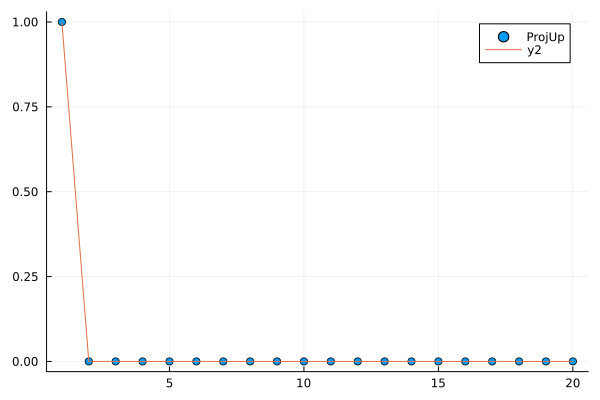

In [17]:
anim = @animate for i=1:nsteps
    fig = plot(real([measureProjUp(evolved[i],j) for j in 1:nn]), seriestype=:scatter, label="ProjUp")
    plot!(fig, real([measureProjUp(evolved[i],j) for j in 1:nn]))
end;
gif(anim, "evolution.gif", fps=10)

┌ Info: Saved animation to c:\Users\mariu\GithubCloneTN\TN_Notebooks\Lecture3\evolution.gif
└ @ Plots C:\Users\mariu\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\mariu\\GithubCloneTN\\TN_Notebooks\\Lecture3\\evolution.gif")
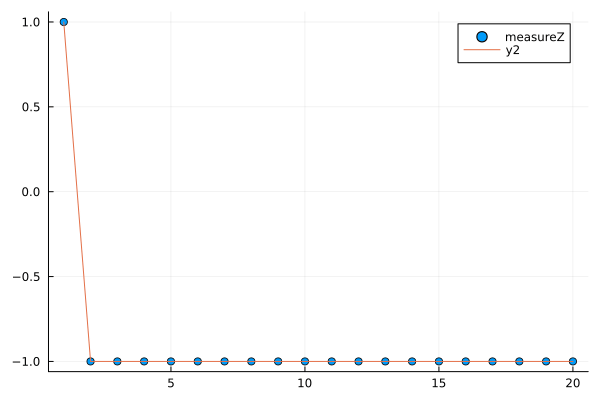

In [18]:
anim = @animate for i=1:nsteps
    fig = plot(real([measureZ(evolved[i],j) for j in 1:nn]), seriestype=:scatter, label="measureZ")
    plot!(fig, real([measureZ(evolved[i],j) for j in 1:nn]))
end;
gif(anim, "evolution.gif", fps=10)

## Exercise 3

The file `onSiteEnergies.dat` contains 20 real numbers representing the values of the $h_i$ terms apparing in the Hamiltonian:

$$
H = -J \sum_{i=1}^{N-1} \sigma_-^{i} \sigma_+^{i+1} + \sigma_+^{i} \sigma_-^{i+1} -\sum_{i=1}^N h_i \sigma_z^i
$$ 

You can read the file by using, for example, the library `DelimitedFiles` and executing the command:
`readdlm("onSiteEnergies.dat")` from within this folder, or by providing the relative/absolute path to the file. Though in the presence of an inhomogeneous magnetic field the relation $[H,N_z]$ still holds.

1. Determine, by numerical means, the eigensystem of the Hamiltonian in the single excitation subspace, that is the space spanned by the _position_ basis $\left \{\ket{i} \right \}_{i=1}^{20}$, where the state $\ket{i}$ has the spin up at site $i$. This is again a tridiagonal matrix...
2. Determine the numerically exact evolution of the  initial state $\ket{\psi_0} = \ket{1}$ using the result of the previous point. Record the probabilities $|\braket{j|\psi(t)}|^2,\; j=1,2,\ldots,20$ for $t=0,0.1,0.2,\ldots,10$.
3. Determine the MPO corresponding to the same Hamiltonian, the MPO corresponding to e 4-th order expansion of $e^{-i H t}$, as done in the companion lecture-notebook.
4. Compare the ``exact'' and the MPO-MPS solutions by assesing the probabilities of point 2, as determined by the MPS-MPO evolution, at the same times as in point 2.

Physically speaking: What do you observe? What is happening?

In [19]:
# read the file
using DelimitedFiles
magn = vec(readdlm("onSiteEnergies.dat"))

20-element Vector{Float64}:
 -0.40597522155704313
  0.06311886533873023
 -0.027391856370233322
  0.05164581701670314
 -0.10602566017476933
  1.2781192267984953
  0.0052442729244930935
 -0.34985879485059296
 -0.41641137909703224
 -0.7289809351210947
 -0.43261784646346463
  0.3845239658146329
  0.7583440005193743
 -0.8973170368882014
 -0.49283562442386164
  0.23709795779942733
 -0.5493136725543539
  0.3387355784065831
 -0.6609103668676712
  0.8886171325212545

In [20]:
#For the exact time vol: Modify funktion from ex. 1
function solExactHam(nn::Int, jj::Float64, h::Vector{Float64}, t::Float64)::Vector{ComplexF64}
    J = jj
    N = nn
    h = h
    dl = -J*ones(ComplexF64, nn-1)

    d = zeros(ComplexF64, N) 
    for l in 1:N
        d[l] = (-1.)*sum(h) + (2.)*h[l]
    end
    du = dl
    Tri = Tridiagonal(dl, d, du)
    eigenval, eigenvek = eigen(Tri)

    # Initial state: (up, dn, dn, ...) -> (1, 0, 0) -> Projection on an eigenstate is the first component of that state.
    coeffs = eigenvek[1, :]
    #time evolution
    for l in range(1, N)
        coeffs[l] = coeffs[l]*exp( - 1im*t*eigenval[l])
    end

    # construct back to the state

    return eigenvek*coeffs
end

solExactHam (generic function with 2 methods)

In [21]:
exactStates = []
for te in 0:0.01:10
    push!(exactStates, solExactHam(20, 1., magn, te))
end
exactStates

1001-element Vector{Any}:
 ComplexF64[0.9999999999999991 + 0.0im, -2.581268532253489e-15 + 0.0im, -2.345346139520643e-15 + 0.0im, -6.938893903907228e-16 + 0.0im, -1.2212453270876722e-15 + 0.0im, -1.2247147740396258e-15 + 0.0im, -1.9741153156616065e-15 + 0.0im, 6.158268339717665e-16 + 0.0im, -2.1718737919229625e-15 + 0.0im, 1.5759962779249292e-15 + 0.0im, 1.734723475976807e-17 + 0.0im, 1.2059038663470023e-16 + 0.0im, -4.87890977618477e-18 + 0.0im, -6.423897871976614e-17 + 0.0im, 1.400247105765029e-16 + 0.0im, -3.0357660829594124e-16 + 0.0im, -5.068645156369733e-17 + 0.0im, 3.848375611237298e-16 + 0.0im, -3.653422508097248e-17 + 0.0im, -1.121336096893133e-16 + 0.0im]
 ComplexF64[0.9999468707182617 - 0.002502127252243726im, 7.192992473081805e-5 + 0.009999371288289458im, -4.999698483651449e-5 + 4.076634383689236e-7im, -1.5047645490762207e-9 - 1.6665629543055616e-7im, 4.166415268347379e-10 - 3.717965822366831e-12im, 1.0019762797242038e-14 + 8.332513281791853e-13im, -3.3133218391157016e-15 +

In [22]:
normCoorect = true
for vec in exactStates
    if !( norm(vec) ≈ 1)
        normCoorect = false
    end
end
normCoorect


true

In [23]:
# MPO Implement
opsum = OpSum()
for bond in 1:nn-1
    #note that the sintax allows for constants to appear before the operator string
    opsum += -1. * jj, "S-", bond, "S+", bond+1
    opsum += -1. * jj, "S+", bond, "S-", bond+1
end
for l in 1:nn
    opsum += magn[l], "Z", l
end

ham = MPO(opsum, system)

20-element MPO:
 ((dim=4|id=827|"Link,l=1"), (dim=2|id=112|"S=1/2,Site,n=1")', (dim=2|id=112|"S=1/2,Site,n=1"))
 ((dim=4|id=827|"Link,l=1"), (dim=4|id=591|"Link,l=2"), (dim=2|id=420|"S=1/2,Site,n=2")', (dim=2|id=420|"S=1/2,Site,n=2"))
 ((dim=4|id=591|"Link,l=2"), (dim=4|id=324|"Link,l=3"), (dim=2|id=5|"S=1/2,Site,n=3")', (dim=2|id=5|"S=1/2,Site,n=3"))
 ((dim=4|id=324|"Link,l=3"), (dim=4|id=596|"Link,l=4"), (dim=2|id=900|"S=1/2,Site,n=4")', (dim=2|id=900|"S=1/2,Site,n=4"))
 ((dim=4|id=596|"Link,l=4"), (dim=4|id=216|"Link,l=5"), (dim=2|id=868|"S=1/2,Site,n=5")', (dim=2|id=868|"S=1/2,Site,n=5"))
 ((dim=4|id=216|"Link,l=5"), (dim=4|id=920|"Link,l=6"), (dim=2|id=987|"S=1/2,Site,n=6")', (dim=2|id=987|"S=1/2,Site,n=6"))
 ((dim=4|id=920|"Link,l=6"), (dim=4|id=988|"Link,l=7"), (dim=2|id=729|"S=1/2,Site,n=7")', (dim=2|id=729|"S=1/2,Site,n=7"))
 ((dim=4|id=988|"Link,l=7"), (dim=4|id=692|"Link,l=8"), (dim=2|id=545|"S=1/2,Site,n=8")', (dim=2|id=545|"S=1/2,Site,n=8"))
 ((dim=4|id=692|"Link,l=8"), (d

In [24]:
deltat = 0.01
nsteps = Int(round(10/deltat))
hdeltat = deltat * ham
#build an MPO with the operator "Id" on each site
theOne = MPO(system,"Id")
factor(k) = (-1im)^k / factorial(k)
#As not to have all the indices of hdeltat contracted with each other, we prime the second one and then we contract the first index of the second one with the first index of the first one, and then we lower the second prime level to first prime level.
h2 = mapprime(prime(hdeltat)*hdeltat,2 =>1)
h3 = mapprime(prime(hdeltat) * h2,2 =>1)
terms = [theOne, factor(1)*hdeltat, factor(2)*h2, factor(3)*h3];
appo = terms[1];
for t in terms[2:end]
    appo = t + appo
end
h4thOrder = appo;
#h4thOrder = +(terms...; cutoff=1e-18);

20-element MPO:
 ((dim=2|id=112|"S=1/2,Site,n=1")', (dim=2|id=112|"S=1/2,Site,n=1"), (dim=8|id=519|"Link,l=1"))
 ((dim=2|id=420|"S=1/2,Site,n=2")', (dim=2|id=420|"S=1/2,Site,n=2"), (dim=14|id=581|"Link,l=2"), (dim=8|id=519|"Link,l=1"))
 ((dim=2|id=5|"S=1/2,Site,n=3")', (dim=2|id=5|"S=1/2,Site,n=3"), (dim=14|id=652|"Link,l=3"), (dim=14|id=581|"Link,l=2"))
 ((dim=2|id=900|"S=1/2,Site,n=4")', (dim=2|id=900|"S=1/2,Site,n=4"), (dim=19|id=348|"Link,l=4"), (dim=14|id=652|"Link,l=3"))
 ((dim=2|id=868|"S=1/2,Site,n=5")', (dim=2|id=868|"S=1/2,Site,n=5"), (dim=14|id=294|"Link,l=5"), (dim=19|id=348|"Link,l=4"))
 ((dim=2|id=987|"S=1/2,Site,n=6")', (dim=2|id=987|"S=1/2,Site,n=6"), (dim=14|id=759|"Link,l=6"), (dim=14|id=294|"Link,l=5"))
 ((dim=2|id=729|"S=1/2,Site,n=7")', (dim=2|id=729|"S=1/2,Site,n=7"), (dim=14|id=628|"Link,l=7"), (dim=14|id=759|"Link,l=6"))
 ((dim=2|id=545|"S=1/2,Site,n=8")', (dim=2|id=545|"S=1/2,Site,n=8"), (dim=14|id=636|"Link,l=8"), (dim=14|id=628|"Link,l=7"))
 ((dim=2|id=668|"S

In [25]:
evolved = Vector{MPS}()
push!(evolved, psi0)
for j=2:nsteps
    push!(evolved, noprime(h4thOrder * evolved[end]))
end

evolved[1]

20-element MPS:
 ((dim=2|id=112|"S=1/2,Site,n=1"), (dim=1|id=441|"Link,l=1"))
 ((dim=2|id=420|"S=1/2,Site,n=2"), (dim=1|id=441|"Link,l=1"), (dim=1|id=256|"Link,l=2"))
 ((dim=2|id=5|"S=1/2,Site,n=3"), (dim=1|id=256|"Link,l=2"), (dim=1|id=594|"Link,l=3"))
 ((dim=2|id=900|"S=1/2,Site,n=4"), (dim=1|id=594|"Link,l=3"), (dim=1|id=798|"Link,l=4"))
 ((dim=2|id=868|"S=1/2,Site,n=5"), (dim=1|id=798|"Link,l=4"), (dim=1|id=326|"Link,l=5"))
 ((dim=2|id=987|"S=1/2,Site,n=6"), (dim=1|id=326|"Link,l=5"), (dim=1|id=557|"Link,l=6"))
 ((dim=2|id=729|"S=1/2,Site,n=7"), (dim=1|id=557|"Link,l=6"), (dim=1|id=874|"Link,l=7"))
 ((dim=2|id=545|"S=1/2,Site,n=8"), (dim=1|id=874|"Link,l=7"), (dim=1|id=632|"Link,l=8"))
 ((dim=2|id=668|"S=1/2,Site,n=9"), (dim=1|id=632|"Link,l=8"), (dim=1|id=551|"Link,l=9"))
 ((dim=2|id=280|"S=1/2,Site,n=10"), (dim=1|id=551|"Link,l=9"), (dim=1|id=48|"Link,l=10"))
 ((dim=2|id=234|"S=1/2,Site,n=11"), (dim=1|id=48|"Link,l=10"), (dim=1|id=128|"Link,l=11"))
 ((dim=2|id=755|"S=1/2,Site,n=1

In [26]:
# obtain from the MPS the amplitude Psi(j, t) to the respective substate.

# Explicit Representation in the upper space is large

# Construct the substates as MPS's, and calculate the projection to the evolved ones. 

basisJ = []
for l in 1:N
    push!(basisJ, MPS(ComplexF64,system,[(j==l) ? "Up" : "Dn" for j in 1:nn]))
end

In [27]:
amplitudes = []
for evol in evolved
    amp = zeros(ComplexF64, N)
    for l in 1:N
        amp[l] = inner(basisJ[l], evol)
    end
    push!(amplitudes, amp)
end

In [28]:
amplitudes[400]

20-element Vector{ComplexF64}:
   -0.19806716975458938 + 0.08100002465686842im
   -0.18376839154524646 + 0.2668514965543459im
   -0.09712817253828605 + 0.2280588202492209im
   -0.20187660044954903 - 0.4641296570993631im
     -0.517780904607713 - 0.2667343252253624im
   -0.16501822875374086 - 0.11969654743138144im
   0.009090436667471327 - 0.25245202192342664im
    0.21257166324729942 + 0.07740669544690787im
      -0.09951273768559 + 0.1303727704106334im
   -0.02970349301002113 - 0.07775931303685253im
   0.040513680855319104 - 0.0020992018811556413im
   0.007122627223906328 + 0.015869617958116495im
 -0.0029338218028831502 + 0.005075999012849541im
  -0.000953299331163757 - 0.0016212354105279029im
  0.0005840254870764564 - 0.0001716019222029822im
   8.228418234752529e-5 + 0.00015684847098701508im
  -3.836706769704515e-5 + 1.2919298234120889e-5im
  -7.442986924109064e-7 - 2.0008667712127485e-6im
 -7.059775423510841e-15 + 3.148689965081706e-15im
  8.894514976028716e-16 - 5.156077687444953e-

In [29]:
exactStates[400]

20-element Vector{ComplexF64}:
   -0.19806704211251494 + 0.08100035187468271im
   -0.18376802567715664 + 0.26685086537547015im
   -0.09712823478811956 + 0.22806022280745844im
   -0.20187727370006267 - 0.46413082632078195im
    -0.5177812642518285 - 0.2667325632600205im
   -0.16501907784622066 - 0.11969627910968153im
    0.00909144112304654 - 0.25245182307881137im
    0.21257228521552524 + 0.07740863305152856im
   -0.09950821502609374 + 0.13037434198455516im
  -0.029701398750389754 - 0.07776416404972816im
    0.04050939894033522 - 0.002100229427348501im
   0.007126188145672824 + 0.015872675515897938im
 -0.0029364158881085398 + 0.005074543314142527im
 -0.0009573280788882334 - 0.0016205742896513197im
  0.0005830130627034719 - 0.00016654158152740677im
   8.570611226216881e-5 + 0.00015885275765188206im
  -4.768270463036189e-5 + 1.2006794545196407e-5im
  -5.787768029569651e-6 - 1.1075250593074704e-5im
   2.884213393541876e-6 - 6.026412965460269e-7im
   3.837452202131308e-7 + 5.18333977802903

## Exercise 4

Consider the Hamiltonian

$$
H = -J \sum_{i=1}^{N-1} \sigma_-^{i} \sigma_+^{i+1} + \sigma_+^{i} \sigma_-^{i+1} 
$$ 

The initial state is this time the state 
$$
\ket{\psi_0} = \sigma_+^1 \sigma_+^2 \ket{0},
$$
where $\ket{0}$ indicates the state with all the spin down (no excitations, if you want). The new state has two spins up at sites 1 and 2 and the remaining down. Since $H$ conserves the number of spin up, the evolution lives in the space $H_{|N=2}$.
Since we have the analytic solution for the single excitation space, 
$$
\ket{\phi_k} = \sum_{j=1}^N \sqrt{\frac{2}{N+1}} \sin \left (\frac{\pi k j}{N+1}\right ) \ket{j}
$$

$$
\epsilon_k = -2 J \cos \left( \frac{k \pi}{N+1} \right )
$$
we can detrmine the solution of the two excitation case 
$$
\ket{\psi(t)} = \sum_{j_1 < j_2} \psi_{j_1,j_2}(t) \ket{j_1,j_2}
$$
by means of Slater determinant:

$$
\psi_{j_1,j_2}(t) = \frac{1}{\sqrt{2}} \det 
\begin{pmatrix}
S(j_1,j_1^{0},t) & S(j_1,j_2^{0},t) \\
 S(j_2,j_1^{0},t) & S(j_2,j_2^{0},t)
\end{pmatrix}
$$
where $S(j_m,j_n^0,t)$ are the single particle amplitudes at position $j_m$ when the excitation is at site $j_n^0$ at time $t=0$, i.e.
$$
S(j_m,j_n^0,t) = \sum_{k=1}^N e^{-i t \epsilon_k} \frac{2}{N+1} \sin \left (\frac{\pi k j_m}{N+1}\right ) \sin \left (\frac{\pi k j_n^0}{N+1}\right ).
$$

1. Determine the probabilities $|\psi_{j_1,j_2}(t)|^2\; j_1,j_2 = 1,2,...,\ldots,20$ for $t=0,0.1,0.2,\ldots,10$ using the exact, Slater-determinant based, solution for the same time-steps as in the previous exercise starting from $\ket{\psi_0}$.
2. By using the MPO defined in the companion notebook, and the corresponding $4$-th order expansion of $e^{-i H t}$, determine the evolution of the same initial state and the probabilities $|\psi_{j_1,j_2}(t)|^2\; j_1,j_2 = 1,2,...,\ldots,20$ for $t=0,0.1,0.2,\ldots,10$.
3. Compare, either numerically or graphically, the occupation probabilities obtained at point 1. and 2..

In [30]:
# analytische definitionen. 
function eps(k)
    return -2*J*cos(k*pi/(N+1))
end

function S(j_m, j_n_0, t)
    res = 0
    for k in 1:N
        res += exp(-1*1im*eps(k)*t)*2/(N+1)*sin(pi*k*j_m/(N+1))*sin(pi*k*j_n_0/(N+1))
    end
    return res
end
S(1, 2, 3)



4.9439619065339e-17 - 0.1619154733067904im

In [31]:
function Psi_1_2(j_1, j_2, t)
    return (S(j_1, 1, t)*S(j_2, 2, t) - S(j_1, 2, t)*S(j_2, 1, t)) # 1/sqrt 2 weg !!!
end
Psi_1_2(1, 2, 3) 

0.04530746892485063 + 3.896457676034064e-18im

In [32]:
# Obtain the same amplitudes from the MPS 

nn = 20
jj=1.0
system = siteinds("S=1/2",nn)
psi0= MPS(ComplexF64,system,[(j==1 || j==2) ? "Up" : "Dn" for j in 1:nn]);
#Set the orthogonality center to the first site
orthogonalize!(psi0,1)

20-element MPS:
 ((dim=2|id=671|"S=1/2,Site,n=1"), (dim=1|id=494|"Link,l=1"))
 ((dim=2|id=555|"S=1/2,Site,n=2"), (dim=1|id=814|"Link,l=2"), (dim=1|id=494|"Link,l=1"))
 ((dim=2|id=140|"S=1/2,Site,n=3"), (dim=1|id=572|"Link,l=3"), (dim=1|id=814|"Link,l=2"))
 ((dim=2|id=753|"S=1/2,Site,n=4"), (dim=1|id=160|"Link,l=4"), (dim=1|id=572|"Link,l=3"))
 ((dim=2|id=270|"S=1/2,Site,n=5"), (dim=1|id=183|"Link,l=5"), (dim=1|id=160|"Link,l=4"))
 ((dim=2|id=379|"S=1/2,Site,n=6"), (dim=1|id=201|"Link,l=6"), (dim=1|id=183|"Link,l=5"))
 ((dim=2|id=974|"S=1/2,Site,n=7"), (dim=1|id=952|"Link,l=7"), (dim=1|id=201|"Link,l=6"))
 ((dim=2|id=7|"S=1/2,Site,n=8"), (dim=1|id=55|"Link,l=8"), (dim=1|id=952|"Link,l=7"))
 ((dim=2|id=806|"S=1/2,Site,n=9"), (dim=1|id=442|"Link,l=9"), (dim=1|id=55|"Link,l=8"))
 ((dim=2|id=283|"S=1/2,Site,n=10"), (dim=1|id=261|"Link,l=10"), (dim=1|id=442|"Link,l=9"))
 ((dim=2|id=804|"S=1/2,Site,n=11"), (dim=1|id=113|"Link,l=11"), (dim=1|id=261|"Link,l=10"))
 ((dim=2|id=397|"S=1/2,Site,n=1

In [33]:
opsum = OpSum()
for bond in 1:nn-1
    #note that the sintax allows for constants to appear before the operator string
    opsum += -1. * jj, "S-", bond, "S+", bond+1
    opsum += -1. * jj, "S+", bond, "S-", bond+1
end
ham = MPO(opsum, system)

20-element MPO:
 ((dim=4|id=978|"Link,l=1"), (dim=2|id=671|"S=1/2,Site,n=1")', (dim=2|id=671|"S=1/2,Site,n=1"))
 ((dim=4|id=978|"Link,l=1"), (dim=4|id=307|"Link,l=2"), (dim=2|id=555|"S=1/2,Site,n=2")', (dim=2|id=555|"S=1/2,Site,n=2"))
 ((dim=4|id=307|"Link,l=2"), (dim=4|id=37|"Link,l=3"), (dim=2|id=140|"S=1/2,Site,n=3")', (dim=2|id=140|"S=1/2,Site,n=3"))
 ((dim=4|id=37|"Link,l=3"), (dim=4|id=414|"Link,l=4"), (dim=2|id=753|"S=1/2,Site,n=4")', (dim=2|id=753|"S=1/2,Site,n=4"))
 ((dim=4|id=414|"Link,l=4"), (dim=4|id=874|"Link,l=5"), (dim=2|id=270|"S=1/2,Site,n=5")', (dim=2|id=270|"S=1/2,Site,n=5"))
 ((dim=4|id=874|"Link,l=5"), (dim=4|id=711|"Link,l=6"), (dim=2|id=379|"S=1/2,Site,n=6")', (dim=2|id=379|"S=1/2,Site,n=6"))
 ((dim=4|id=711|"Link,l=6"), (dim=4|id=843|"Link,l=7"), (dim=2|id=974|"S=1/2,Site,n=7")', (dim=2|id=974|"S=1/2,Site,n=7"))
 ((dim=4|id=843|"Link,l=7"), (dim=4|id=41|"Link,l=8"), (dim=2|id=7|"S=1/2,Site,n=8")', (dim=2|id=7|"S=1/2,Site,n=8"))
 ((dim=4|id=41|"Link,l=8"), (dim=4

In [34]:
deltat = 0.01
nsteps = Int(round(10/deltat))
hdeltat = deltat * ham
#build an MPO with the operator "Id" on each site
theOne = MPO(system,"Id")
factor(k) = (-1im)^k / factorial(k)
#As not to have all the indices of hdeltat contracted with each other, we prime the second one and then we contract the first index of the second one with the first index of the first one, and then we lower the second prime level to first prime level.
h2 = mapprime(prime(hdeltat)*hdeltat,2 =>1)
h3 = mapprime(prime(hdeltat) * h2,2 =>1)
terms = [theOne, factor(1)*hdeltat, factor(2)*h2, factor(3)*h3];
appo = terms[1];
for t in terms[2:end]
    appo = t + appo
end
h4thOrder = appo;
#h4thOrder = +(terms...; cutoff=1e-18);

20-element MPO:
 ((dim=2|id=671|"S=1/2,Site,n=1")', (dim=2|id=671|"S=1/2,Site,n=1"), (dim=8|id=76|"Link,l=1"))
 ((dim=2|id=555|"S=1/2,Site,n=2")', (dim=2|id=555|"S=1/2,Site,n=2"), (dim=14|id=657|"Link,l=2"), (dim=8|id=76|"Link,l=1"))
 ((dim=2|id=140|"S=1/2,Site,n=3")', (dim=2|id=140|"S=1/2,Site,n=3"), (dim=14|id=569|"Link,l=3"), (dim=14|id=657|"Link,l=2"))
 ((dim=2|id=753|"S=1/2,Site,n=4")', (dim=2|id=753|"S=1/2,Site,n=4"), (dim=14|id=182|"Link,l=4"), (dim=14|id=569|"Link,l=3"))
 ((dim=2|id=270|"S=1/2,Site,n=5")', (dim=2|id=270|"S=1/2,Site,n=5"), (dim=14|id=94|"Link,l=5"), (dim=14|id=182|"Link,l=4"))
 ((dim=2|id=379|"S=1/2,Site,n=6")', (dim=2|id=379|"S=1/2,Site,n=6"), (dim=14|id=256|"Link,l=6"), (dim=14|id=94|"Link,l=5"))
 ((dim=2|id=974|"S=1/2,Site,n=7")', (dim=2|id=974|"S=1/2,Site,n=7"), (dim=16|id=372|"Link,l=7"), (dim=14|id=256|"Link,l=6"))
 ((dim=2|id=7|"S=1/2,Site,n=8")', (dim=2|id=7|"S=1/2,Site,n=8"), (dim=14|id=102|"Link,l=8"), (dim=16|id=372|"Link,l=7"))
 ((dim=2|id=806|"S=1/2

In [35]:
evolved = Vector{MPS}()
push!(evolved, psi0)
for j=2:nsteps
    push!(evolved, noprime(h4thOrder * evolved[end]))
end

evolved[1]

20-element MPS:
 ((dim=2|id=671|"S=1/2,Site,n=1"), (dim=1|id=494|"Link,l=1"))
 ((dim=2|id=555|"S=1/2,Site,n=2"), (dim=1|id=814|"Link,l=2"), (dim=1|id=494|"Link,l=1"))
 ((dim=2|id=140|"S=1/2,Site,n=3"), (dim=1|id=572|"Link,l=3"), (dim=1|id=814|"Link,l=2"))
 ((dim=2|id=753|"S=1/2,Site,n=4"), (dim=1|id=160|"Link,l=4"), (dim=1|id=572|"Link,l=3"))
 ((dim=2|id=270|"S=1/2,Site,n=5"), (dim=1|id=183|"Link,l=5"), (dim=1|id=160|"Link,l=4"))
 ((dim=2|id=379|"S=1/2,Site,n=6"), (dim=1|id=201|"Link,l=6"), (dim=1|id=183|"Link,l=5"))
 ((dim=2|id=974|"S=1/2,Site,n=7"), (dim=1|id=952|"Link,l=7"), (dim=1|id=201|"Link,l=6"))
 ((dim=2|id=7|"S=1/2,Site,n=8"), (dim=1|id=55|"Link,l=8"), (dim=1|id=952|"Link,l=7"))
 ((dim=2|id=806|"S=1/2,Site,n=9"), (dim=1|id=442|"Link,l=9"), (dim=1|id=55|"Link,l=8"))
 ((dim=2|id=283|"S=1/2,Site,n=10"), (dim=1|id=261|"Link,l=10"), (dim=1|id=442|"Link,l=9"))
 ((dim=2|id=804|"S=1/2,Site,n=11"), (dim=1|id=113|"Link,l=11"), (dim=1|id=261|"Link,l=10"))
 ((dim=2|id=397|"S=1/2,Site,n=1

In [36]:
function Amp(j_1, j_2, t)
    MPS_t = evolved[Int(round(t/deltat))+1]
    return inner(MPS_t, MPS(ComplexF64,system,[(j==j_1 || j==j_2) ? "Up" : "Dn" for j in 1:nn]))
end

Amp (generic function with 1 method)

In [37]:
Amp(1, 2, 3)

0.04530668206499567 + 4.6546856220028144e-8im

In [38]:
Psi_1_2(1, 2, 0)

0.9999999999999998 + 0.0im

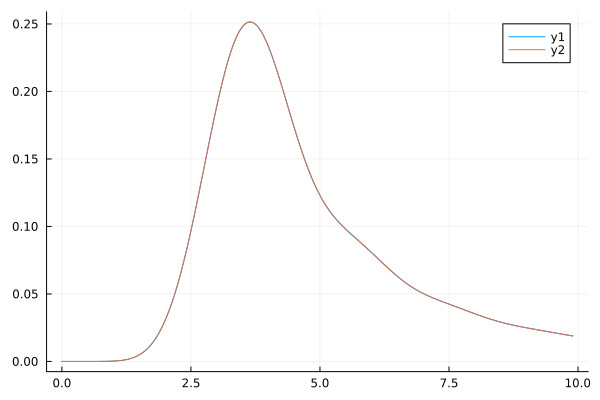

In [39]:
times = 0:deltat:9.9

plot(times, norm.(Psi_1_2.(5, 6, times)))
plot!(times, norm.(Amp.(5, 6, times)))

## Exercize 5

In [1]:
using Pkg
Pkg.activate("../")
using ITensors
using ITensorMPS
using Plots
using LinearAlgebra

  Activating project at `c:\Users\mariu\GithubCloneTN\TN_Notebooks`


Suppose you want to the evolution an initial state of the same system of $N=20$ spins where, this time, $N_{up}=10$ spins are initially up (and the remaining down). The spins up can be placed where you like. Is it possible to determine the evolution using the exact solution (with Slater determinant generalized to $M=10$)? How complex is it?

1. Prepare the MPS representing an initial state with 10 spin up at the beginning of the chain.
2. Prepare (copy) the MPO for the Hamiltonian

$$
H = -J \sum_{i=1}^{N-1} \sigma_-^{i} \sigma_+^{i+1} + \sigma_+^{i} \sigma_-^{i+1} 
$$ 
for $J=1.0$ and $N=20$.

3. Determine the MPO for the 4-th order expansion of  $e^{-itH}$.

4. Evolve the initial state for the same time range and time step used in the previous exercizes.


In [2]:
# Obtain the same amplitudes from the MPS 

nn = 20
jj=1.0
system = siteinds("S=1/2",nn)
InitialUps = [1, 2, 3, 4, 5, 20, 19, 18, 17, 16]
psi0= MPS(ComplexF64,system,[j in InitialUps ? "Up" : "Dn" for j in 1:nn]);
#Set the orthogonality center to the first site
orthogonalize!(psi0,1)

20-element MPS:
 ((dim=2|id=184|"S=1/2,Site,n=1"), (dim=1|id=520|"Link,l=1"))
 ((dim=2|id=583|"S=1/2,Site,n=2"), (dim=1|id=344|"Link,l=2"), (dim=1|id=520|"Link,l=1"))
 ((dim=2|id=648|"S=1/2,Site,n=3"), (dim=1|id=5|"Link,l=3"), (dim=1|id=344|"Link,l=2"))
 ((dim=2|id=900|"S=1/2,Site,n=4"), (dim=1|id=216|"Link,l=4"), (dim=1|id=5|"Link,l=3"))
 ((dim=2|id=337|"S=1/2,Site,n=5"), (dim=1|id=169|"Link,l=5"), (dim=1|id=216|"Link,l=4"))
 ((dim=2|id=563|"S=1/2,Site,n=6"), (dim=1|id=701|"Link,l=6"), (dim=1|id=169|"Link,l=5"))
 ((dim=2|id=449|"S=1/2,Site,n=7"), (dim=1|id=620|"Link,l=7"), (dim=1|id=701|"Link,l=6"))
 ((dim=2|id=908|"S=1/2,Site,n=8"), (dim=1|id=149|"Link,l=8"), (dim=1|id=620|"Link,l=7"))
 ((dim=2|id=173|"S=1/2,Site,n=9"), (dim=1|id=984|"Link,l=9"), (dim=1|id=149|"Link,l=8"))
 ((dim=2|id=108|"S=1/2,Site,n=10"), (dim=1|id=625|"Link,l=10"), (dim=1|id=984|"Link,l=9"))
 ((dim=2|id=773|"S=1/2,Site,n=11"), (dim=1|id=948|"Link,l=11"), (dim=1|id=625|"Link,l=10"))
 ((dim=2|id=29|"S=1/2,Site,n=12

In [3]:
opsum = OpSum()
for bond in 1:nn-1
    #note that the sintax allows for constants to appear before the operator string
    opsum += -1. * jj, "S-", bond, "S+", bond+1
    opsum += -1. * jj, "S+", bond, "S-", bond+1
end
ham = MPO(opsum, system)

20-element MPO:
 ((dim=4|id=199|"Link,l=1"), (dim=2|id=184|"S=1/2,Site,n=1")', (dim=2|id=184|"S=1/2,Site,n=1"))
 ((dim=4|id=199|"Link,l=1"), (dim=4|id=788|"Link,l=2"), (dim=2|id=583|"S=1/2,Site,n=2")', (dim=2|id=583|"S=1/2,Site,n=2"))
 ((dim=4|id=788|"Link,l=2"), (dim=4|id=53|"Link,l=3"), (dim=2|id=648|"S=1/2,Site,n=3")', (dim=2|id=648|"S=1/2,Site,n=3"))
 ((dim=4|id=53|"Link,l=3"), (dim=4|id=267|"Link,l=4"), (dim=2|id=900|"S=1/2,Site,n=4")', (dim=2|id=900|"S=1/2,Site,n=4"))
 ((dim=4|id=267|"Link,l=4"), (dim=4|id=281|"Link,l=5"), (dim=2|id=337|"S=1/2,Site,n=5")', (dim=2|id=337|"S=1/2,Site,n=5"))
 ((dim=4|id=281|"Link,l=5"), (dim=4|id=568|"Link,l=6"), (dim=2|id=563|"S=1/2,Site,n=6")', (dim=2|id=563|"S=1/2,Site,n=6"))
 ((dim=4|id=568|"Link,l=6"), (dim=4|id=558|"Link,l=7"), (dim=2|id=449|"S=1/2,Site,n=7")', (dim=2|id=449|"S=1/2,Site,n=7"))
 ((dim=4|id=558|"Link,l=7"), (dim=4|id=903|"Link,l=8"), (dim=2|id=908|"S=1/2,Site,n=8")', (dim=2|id=908|"S=1/2,Site,n=8"))
 ((dim=4|id=903|"Link,l=8"), 

In [4]:
deltat = 0.01
nsteps = Int(round(10/deltat))
hdeltat = deltat * ham
#build an MPO with the operator "Id" on each site
theOne = MPO(system,"Id")
factor(k) = (-1im)^k / factorial(k)
#As not to have all the indices of hdeltat contracted with each other, we prime the second one and then we contract the first index of the second one with the first index of the first one, and then we lower the second prime level to first prime level.
h2 = mapprime(prime(hdeltat)*hdeltat,2 =>1)
h3 = mapprime(prime(hdeltat) * h2,2 =>1)
terms = [theOne, factor(1)*hdeltat, factor(2)*h2, factor(3)*h3];
appo = terms[1];
for t in terms[2:end]
    appo = t + appo
end
h4thOrder = appo;
#h4thOrder = +(terms...; cutoff=1e-18);

20-element MPO:
 ((dim=2|id=184|"S=1/2,Site,n=1")', (dim=2|id=184|"S=1/2,Site,n=1"), (dim=8|id=222|"Link,l=1"))
 ((dim=2|id=583|"S=1/2,Site,n=2")', (dim=2|id=583|"S=1/2,Site,n=2"), (dim=14|id=991|"Link,l=2"), (dim=8|id=222|"Link,l=1"))
 ((dim=2|id=648|"S=1/2,Site,n=3")', (dim=2|id=648|"S=1/2,Site,n=3"), (dim=14|id=294|"Link,l=3"), (dim=14|id=991|"Link,l=2"))
 ((dim=2|id=900|"S=1/2,Site,n=4")', (dim=2|id=900|"S=1/2,Site,n=4"), (dim=14|id=861|"Link,l=4"), (dim=14|id=294|"Link,l=3"))
 ((dim=2|id=337|"S=1/2,Site,n=5")', (dim=2|id=337|"S=1/2,Site,n=5"), (dim=14|id=986|"Link,l=5"), (dim=14|id=861|"Link,l=4"))
 ((dim=2|id=563|"S=1/2,Site,n=6")', (dim=2|id=563|"S=1/2,Site,n=6"), (dim=14|id=533|"Link,l=6"), (dim=14|id=986|"Link,l=5"))
 ((dim=2|id=449|"S=1/2,Site,n=7")', (dim=2|id=449|"S=1/2,Site,n=7"), (dim=16|id=577|"Link,l=7"), (dim=14|id=533|"Link,l=6"))
 ((dim=2|id=908|"S=1/2,Site,n=8")', (dim=2|id=908|"S=1/2,Site,n=8"), (dim=14|id=445|"Link,l=8"), (dim=16|id=577|"Link,l=7"))
 ((dim=2|id=17

In [5]:
evolved = Vector{MPS}()
push!(evolved, psi0)
for j=2:nsteps
    push!(evolved, normalize(noprime(*(h4thOrder, evolved[end]; cutoff=1e-3, maxdim=50))))
    if j % 100 == 0
        println("Step $j / $nsteps done")
    end
end

evolved[1]

Step 100 / 1000 done
Step 200 / 1000 done
Step 300 / 1000 done
Step 400 / 1000 done
Step 500 / 1000 done
Step 600 / 1000 done
Step 700 / 1000 done
Step 800 / 1000 done
Step 900 / 1000 done
Step 1000 / 1000 done


20-element MPS:
 ((dim=2|id=184|"S=1/2,Site,n=1"), (dim=1|id=520|"Link,l=1"))
 ((dim=2|id=583|"S=1/2,Site,n=2"), (dim=1|id=344|"Link,l=2"), (dim=1|id=520|"Link,l=1"))
 ((dim=2|id=648|"S=1/2,Site,n=3"), (dim=1|id=5|"Link,l=3"), (dim=1|id=344|"Link,l=2"))
 ((dim=2|id=900|"S=1/2,Site,n=4"), (dim=1|id=216|"Link,l=4"), (dim=1|id=5|"Link,l=3"))
 ((dim=2|id=337|"S=1/2,Site,n=5"), (dim=1|id=169|"Link,l=5"), (dim=1|id=216|"Link,l=4"))
 ((dim=2|id=563|"S=1/2,Site,n=6"), (dim=1|id=701|"Link,l=6"), (dim=1|id=169|"Link,l=5"))
 ((dim=2|id=449|"S=1/2,Site,n=7"), (dim=1|id=620|"Link,l=7"), (dim=1|id=701|"Link,l=6"))
 ((dim=2|id=908|"S=1/2,Site,n=8"), (dim=1|id=149|"Link,l=8"), (dim=1|id=620|"Link,l=7"))
 ((dim=2|id=173|"S=1/2,Site,n=9"), (dim=1|id=984|"Link,l=9"), (dim=1|id=149|"Link,l=8"))
 ((dim=2|id=108|"S=1/2,Site,n=10"), (dim=1|id=625|"Link,l=10"), (dim=1|id=984|"Link,l=9"))
 ((dim=2|id=773|"S=1/2,Site,n=11"), (dim=1|id=948|"Link,l=11"), (dim=1|id=625|"Link,l=10"))
 ((dim=2|id=29|"S=1/2,Site,n=12